# 01. Corpus et validation

Présenter les données, valider la qualité (accord LLM, cohérence) et documenter les biais (attrition, composition du panel).

## 0. Setup et configuration

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from config import PROJECT_ROOT, RESULTS_DIR, FIGURES_DIR, COLORS, BLOCS_ORDER
warnings.filterwarnings("ignore")

DATA_DIR = PROJECT_ROOT / "data"
FIG_DIR = FIGURES_DIR
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Donnees : {RESULTS_DIR}")

Donnees : d:\Users\Proprietaire\Desktop\Projet_perso\Projets\Revirement_politique_fr_gaza\fr_assemblee_discourse_analysis\data\results


## 1.A Démonstration des choix méthodologiques

Cette section justifie deux choix centraux : *(1) l’impact du panel B4* (sans panel vs avec panel) et *(2) la classification des députés par bloc*.

### 1.A.1 Stance : corpus complet vs Panel B4

Le Panel B4 ne représente pas le corpus : il sélectionne les députés actifs sur ≥18 mois. La comparaison ci-dessous montre **l’écart de stance** selon qu’on utilise le corpus complet ou le panel.

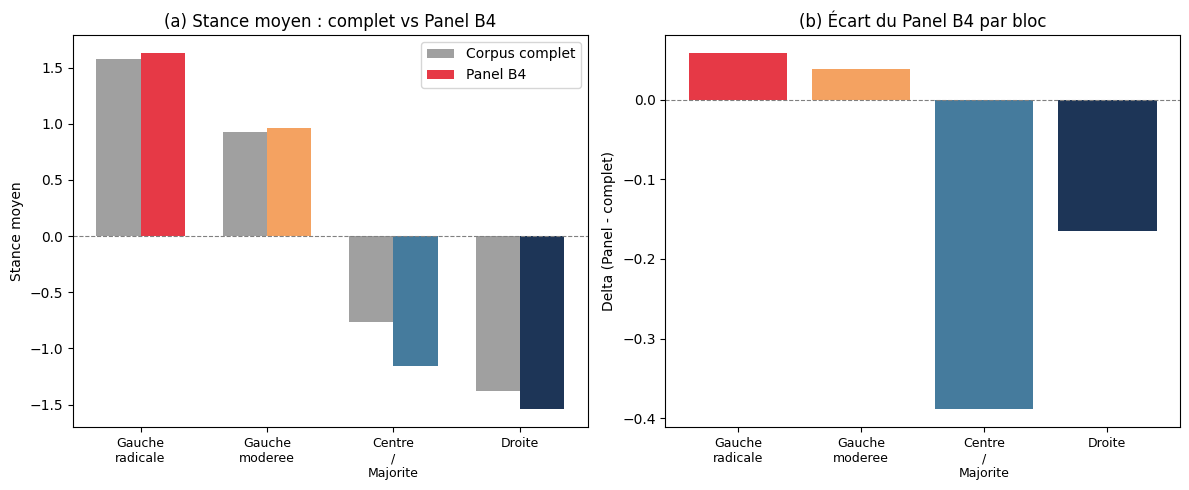

,bloc,stance_complet,stance_panel_b4,delta,n_complet,n_panel
0,Gauche radicale,1.574,1.633,0.059,6838,5549
1,Gauche moderee,0.926,0.965,0.039,971,402
2,Centre / Majorite,-0.769,-1.158,-0.389,1489,475
3,Droite,-1.378,-1.543,-0.165,1476,427



Le Centre est le plus affecté (delta env. -0.39) : le panel B4 surevalue les députés centristes les plus actifs.


In [2]:
# Comparaison Panel B4 vs corpus complet
try:
    pd
except NameError:
    import sys
    from pathlib import Path
    sys.path.insert(0, str(Path.cwd().parent / "src"))
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from config import RESULTS_DIR, FIGURES_DIR, COLORS, BLOCS_ORDER
    FIG_DIR = FIGURES_DIR
comp = pd.read_csv(RESULTS_DIR / "stance_panel_vs_complet.csv")
comp = comp.set_index("bloc").reindex(BLOCS_ORDER).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = np.arange(len(BLOCS_ORDER))
w = 0.35
axes[0].bar(x - w/2, comp["stance_complet"], w, label="Corpus complet", color="#888", alpha=0.8)
axes[0].bar(x + w/2, comp["stance_panel_b4"], w, label="Panel B4", color=[COLORS[b] for b in BLOCS_ORDER])
axes[0].set_xticks(x)
axes[0].set_xticklabels([b.replace(" ", "\n") for b in BLOCS_ORDER], fontsize=9)
axes[0].set_ylabel("Stance moyen")
axes[0].set_title("(a) Stance moyen : complet vs Panel B4")
axes[0].legend()
axes[0].axhline(0, color="gray", ls="--", lw=0.8)

axes[1].bar(x, comp["delta"], color=[COLORS[b] for b in BLOCS_ORDER])
axes[1].set_xticks(x)
axes[1].set_xticklabels([b.replace(" ", "\n") for b in BLOCS_ORDER], fontsize=9)
axes[1].set_ylabel("Delta (Panel - complet)")
axes[1].set_title("(b) Écart du Panel B4 par bloc")
axes[1].axhline(0, color="gray", ls="--", lw=0.8)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_panel_vs_complet.png", dpi=150, bbox_inches="tight")
plt.show()

display(comp[["bloc", "stance_complet", "stance_panel_b4", "delta", "n_complet", "n_panel"]])
print("\nLe Centre est le plus affecté (delta env. -0.39) : le panel B4 surevalue les députés centristes les plus actifs.")

### 1.A.2 Vérification de la classification des députés

La classification `groupe_politique` → `bloc` a été vérifiée contre les sources officielles (Assemblée nationale, data.gouv.fr). Résumé :

- **16 groupes** dans le corpus, tous mappés vers 4 blocs.
- **Changements de dénomination** (2024) : LFI→LFI-NFP, Renaissance→EPR, PS→PS-NFP, ECO→ECO-NFP. Le mapping couvre ces variantes.
- **LIOT** : absent du corpus (ou non distingué).

→ Rapport détaillé : [docs/RAPPORT_EXPLORATION_CLASSIFICATION_GROUPES.md](../docs/RAPPORT_EXPLORATION_CLASSIFICATION_GROUPES.md)

### 1.A.3 Choix Droite / Extreme droite : justification

**Option retenue : 4 blocs, Droite et ED regroupés.**

Le groupe RN (Rassemblement National) et les formations proches (UDR, ex-Reconquête) sont classés dans le bloc « Droite » avec LR et NI. Justification :

1. **Pouvoir statistique** : séparer RN en « Extreme droite » réduirait les effectifs du bloc Droite (LR 320, UDR 87, NI 82 ≈ 489 textes) et créerait un bloc ED à 987 textes. Deséquilibre et comparaisons moins robustes.
2. **Objectif analytique** : la thèse porte sur la *variabilité du Centre* et la *polarisation Gauche–Droite*, pas sur les différences LR vs RN.
3. **Littérature** : les études sur le discours parlementaire français regroupent souvent Droite républicaine et RN pour les analyses de polarisation (spectre gauche–droite).
4. **Alternative** : pour des analyses sensibles à la distinction RN/LR, un `bloc_5` (5 catégories) est documenté dans `src/config.py` (commentaire) et peut être activé en régénérant les données.

*Référence* : plan_analyse §0.5 ; [RAPPORT_EXPLORATION_CLASSIFICATION_GROUPES.md](../docs/RAPPORT_EXPLORATION_CLASSIFICATION_GROUPES.md).

## 1.5 Analyse par groupe politique

Analyse au niveau **groupe** (LFI, RN, LR, etc.) avec les précautions suivantes :

- **Seuils n** : groupes avec n &lt; 30 textes ont des IC larges.
- **Petits groupes** : SOC, ECO, HOR, DEM. Interpréter avec prudence.
- **Période** : corpus couvre XVIe et XVIIe législatures (changements de noms en 2024).

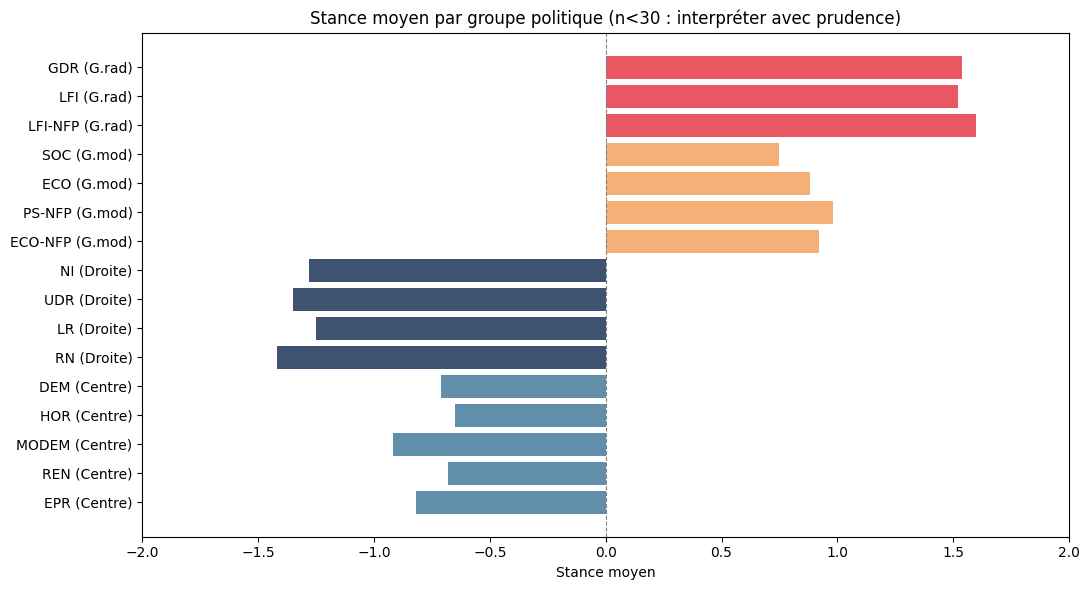

,groupe_politique,bloc,n_textes,stance_mean,stance_std,alerte_n
7,EPR,Centre / Majorite,706,-0.82,0.92,
8,REN,Centre / Majorite,480,-0.68,0.98,
9,MODEM,Centre / Majorite,182,-0.92,0.88,
10,HOR,Centre / Majorite,68,-0.65,1.05,
11,DEM,Centre / Majorite,53,-0.71,0.92,
12,RN,Droite,987,-1.42,0.69,
13,LR,Droite,320,-1.25,0.82,
14,UDR,Droite,87,-1.35,0.71,
15,NI,Droite,82,-1.28,0.78,
4,ECO-NFP,Gauche moderee,483,0.92,0.94,


In [3]:
# Stance par groupe politique
grp = pd.read_csv(RESULTS_DIR / "stance_par_groupe.csv")
bloc_short = {"Gauche radicale": "G.rad", "Gauche moderee": "G.mod", "Centre / Majorite": "Centre", "Droite": "Droite"}
grp["groupe_bloc"] = grp["groupe_politique"] + " (" + grp["bloc"].map(bloc_short) + ")"
grp = grp.sort_values(["bloc", "n_textes"], ascending=[True, False])

fig, ax = plt.subplots(figsize=(11, 6))
colors_grp = grp["bloc"].map(COLORS)
ax.barh(grp["groupe_bloc"], grp["stance_mean"], color=colors_grp, alpha=0.85)
ax.axvline(0, color="gray", ls="--", lw=0.8)
ax.set_xlabel("Stance moyen")
ax.set_title("Stance moyen par groupe politique (n<30 : interpréter avec prudence)")
ax.set_xlim(-2, 2)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_stance_par_groupe.png", dpi=150, bbox_inches="tight")
plt.show()

# Tableau avec indication des petits effectifs
grp["alerte_n"] = grp["n_textes"].apply(lambda x: "⚠" if x < 30 else "")
display(grp[["groupe_politique", "bloc", "n_textes", "stance_mean", "stance_std", "alerte_n"]])

In [4]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent  # notebooks/ -> project root
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = DATA_DIR / "results"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Palette OBLIGATOIRE (brief technique)
COLORS = {
    "Gauche radicale": "#E63946",
    "Gauche moderee": "#F4A261",
    "Centre / Majorite": "#457B9D",
    "Droite": "#1D3557",
    "Extreme droite": "#2A0134",
}
BLOCS_ORDER = ["Gauche radicale", "Gauche moderee", "Centre / Majorite", "Droite"]

# Événements-clés (lignes verticales)
EVENTS = {
    "2023-10-07": "7 oct.",
    "2024-01-26": "CIJ",
    "2024-05-06": "Rafah",
    "2024-10-17": "Sinwar",
    "2024-11-21": "CPI",
    "2025-01-15": "CF",
    "2025-03-15": "Rupture",
}

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 7),
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "serif",
    "axes.grid": True,
    "grid.alpha": 0.25,
})

def add_events(ax, ymax_frac=0.97, fontsize=6.5):
    ylim = ax.get_ylim()
    for date_str, label in EVENTS.items():
        dt = pd.Timestamp(date_str)
        ax.axvline(dt, color="grey", lw=0.8, ls="--", alpha=0.4, zorder=0)
        ax.text(dt, ylim[1] * ymax_frac, label, fontsize=fontsize, ha="center", va="top", color="#777777", rotation=45)

# Chemins corpus
CORPUS_V3 = DATA_DIR / "processed" / "corpus_v3.parquet"
CORPUS_V4 = DATA_DIR / "processed" / "corpus_v4.parquet"
print(f"Données chargées depuis {RESULTS_DIR}")

Données chargées depuis d:\Users\Proprietaire\Desktop\Projet_perso\Projets\Revirement_politique_fr_gaza\fr_assemblee_discourse_analysis\data\results


## 1.1 Vue d'ensemble du corpus

In [5]:
vue_ensemble = pd.read_csv(RESULTS_DIR / "vue_ensemble.csv")
attrition = pd.read_csv(RESULTS_DIR / "attrition_mensuelle.csv")
volume_mensuel = pd.read_csv(RESULTS_DIR / "volume_mensuel.csv")

attrition["month"] = pd.to_datetime(attrition["month"] + "-01")
volume_mensuel["month"] = pd.to_datetime(volume_mensuel["month"] + "-01")

vue_ensemble

,bloc,n_textes,pct_corpus,n_deputes,textes_par_depute,n_twitter,n_an,ratio_tw_an,stance_v3_moyen,stance_v3_std,confidence_v3_moy,engagement_median_tw
0,Gauche radicale,6838,63.47,138,49.6,6227,611,10.19,1.574,0.849,0.924,372.0
1,Gauche moderee,971,9.01,67,14.5,814,157,5.18,0.926,0.950,0.880,113.5
2,Centre / Majorite,1489,13.82,130,11.5,944,545,1.73,-0.769,0.950,0.868,61.5
3,Droite,1476,13.70,124,11.9,1150,326,3.53,-1.378,0.730,0.897,63.0


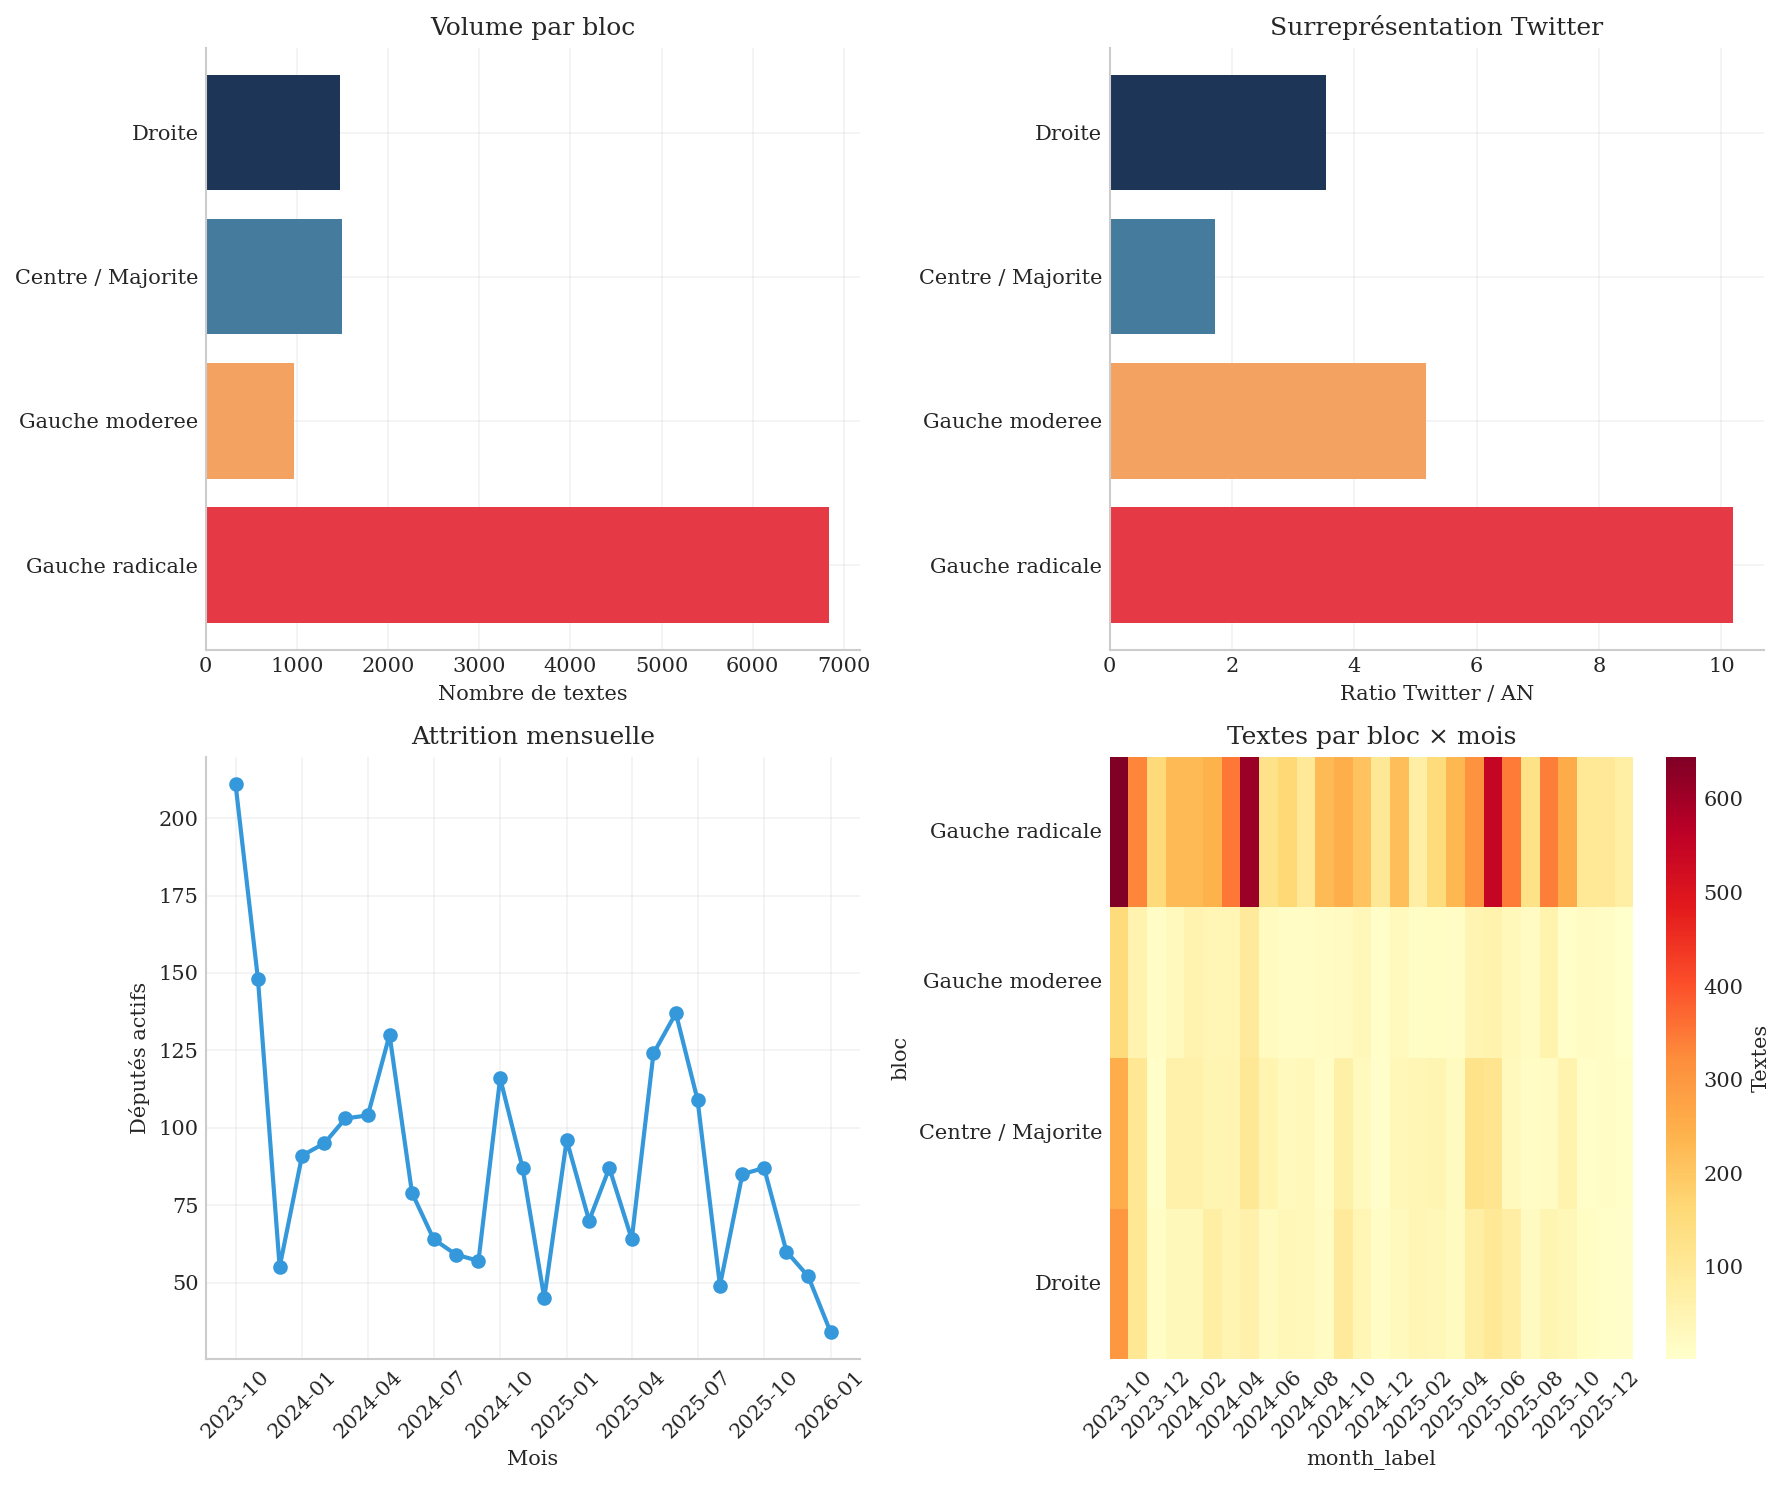

Figure 1 sauvegardée : d:\Users\Proprietaire\Desktop\Projet_perso\Projets\Revirement_politique_fr_gaza\fr_assemblee_discourse_analysis\reports\figures\fig01_corpus_overview.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Stacked bar, textes par bloc
ax = axes[0, 0]
bloc_order = BLOCS_ORDER
vue_ord = vue_ensemble.set_index("bloc").loc[[b for b in bloc_order if b in vue_ensemble["bloc"].values]]
colors = [COLORS.get(b, "#666") for b in vue_ord.index]
ax.barh(vue_ord.index, vue_ord["n_textes"], color=colors)
ax.set_xlabel("Nombre de textes")
ax.set_title("Volume par bloc")

# 2. Ratio Twitter / AN
ax = axes[0, 1]
ax.barh(vue_ord.index, vue_ord["ratio_tw_an"], color=colors)
ax.set_xlabel("Ratio Twitter / AN")
ax.set_title("Surreprésentation Twitter")

# 3. Courbe d'attrition mensuelle
ax = axes[1, 0]
ax.plot(attrition["month"], attrition["n_deputes_actifs"], "o-", color="#3498db", lw=2)
ax.set_xlabel("Mois")
ax.set_ylabel("Députés actifs")
ax.set_title("Attrition mensuelle")
ax.tick_params(axis="x", rotation=45)

# 4. Heatmap bloc x mois
ax = axes[1, 1]
vol = volume_mensuel.copy()
vol["month_label"] = vol["month"].dt.strftime("%Y-%m")
pivot = vol.pivot(index="bloc", columns="month_label", values="n_textes")
pivot = pivot.reindex([b for b in BLOCS_ORDER if b in pivot.index])
sns.heatmap(pivot, ax=ax, cmap="YlOrRd", cbar_kws={"label": "Textes"})
ax.set_title("Textes par bloc × mois")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig01_corpus_overview.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Figure 1 sauvegardée : {FIG_DIR / 'fig01_corpus_overview.png'}")

**Interprétation** : Le corpus est fortement déséquilibré : 63,5 % des textes proviennent de la Gauche radicale (LFI-NFP). L'attrition est marquée : 211 députés actifs en octobre 2023 vs 34 en janvier 2026. Le ratio Twitter/AN est élevé pour la Gauche radicale (10,2), reflétant une mobilisation plus forte sur les réseaux sociaux.

## 1.2 Validation de l'annotation LLM

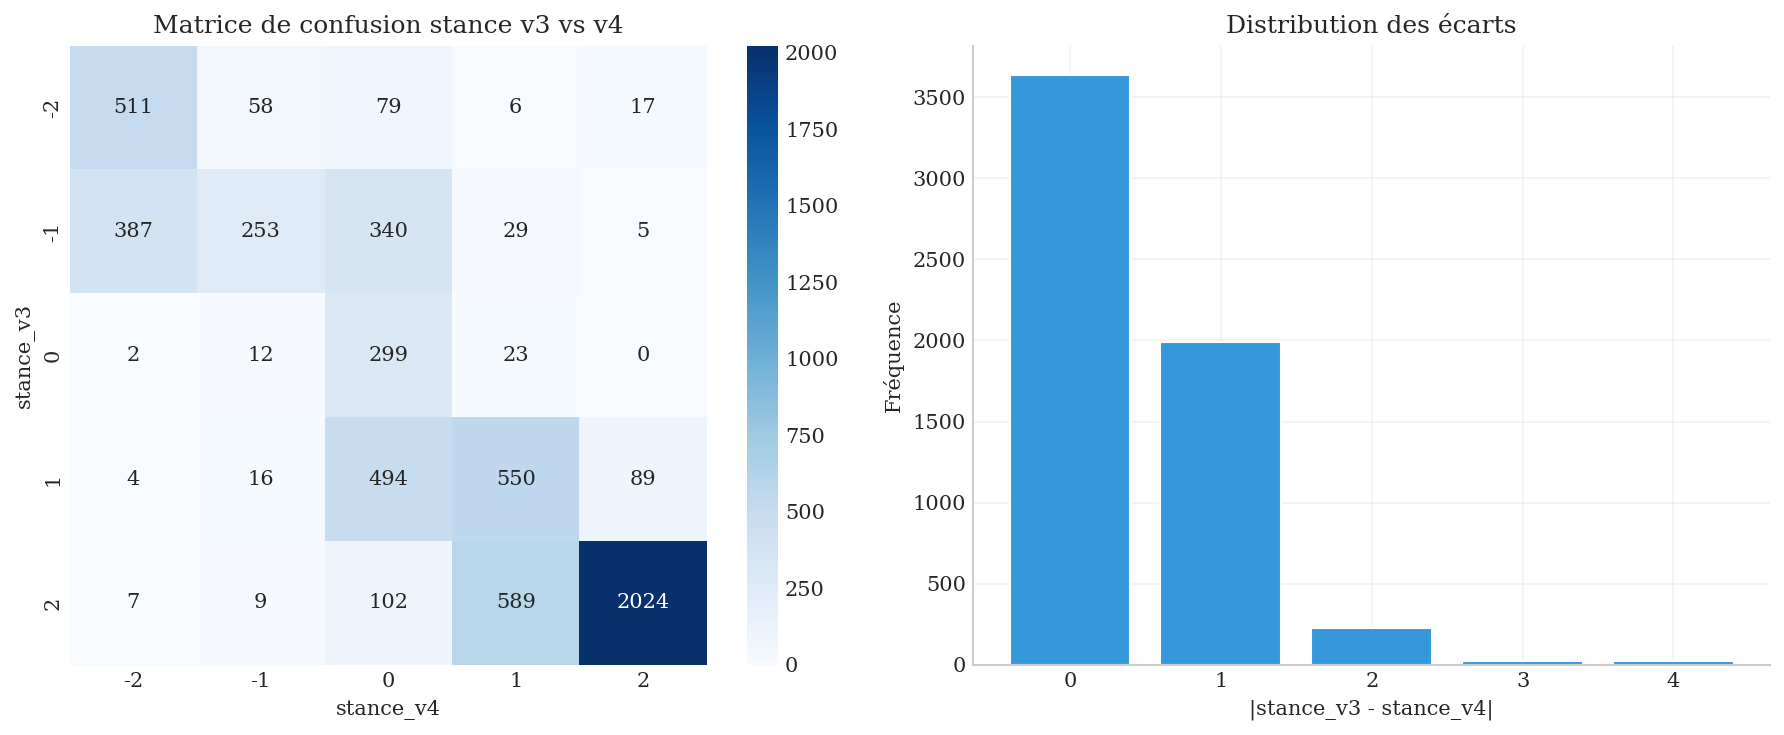

In [7]:
# Figure 2. Matrice de confusion et distribution |stance_v3 - stance_v4|
if CORPUS_V4.exists():
    v4 = pd.read_parquet(CORPUS_V4)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    conf = pd.crosstab(v4["stance_v3"], v4["stance_v4"])
    sns.heatmap(conf, annot=True, fmt="d", cmap="Blues", ax=axes[0])
    axes[0].set_title("Matrice de confusion stance v3 vs v4")
    axes[0].set_xlabel("stance_v4")
    axes[0].set_ylabel("stance_v3")
    diff = (v4["stance_v3"] - v4["stance_v4"]).abs()
    axes[1].hist(diff, bins=range(6), align="left", rwidth=0.8, color="#3498db", edgecolor="white")
    axes[1].set_xlabel("|stance_v3 - stance_v4|")
    axes[1].set_ylabel("Fréquence")
    axes[1].set_title("Distribution des écarts")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig02_interversion_agreement.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Corpus v4 absent, matrice de confusion non générée.")

In [8]:
accord = pd.read_csv(RESULTS_DIR / "accord_v3_v4.csv")
coherence = pd.read_csv(RESULTS_DIR / "coherence_v4.csv")

print("Accord v3/v4 (Spearman ρ):", accord["spearman_rho"].iloc[0])
print("Accord exact (%):", accord["accord_exact_pct"].iloc[0])
print("Accord à ±1 point (%):", accord["accord_a_1pt_pres_pct"].iloc[0])
print("\nTableau de cohérence v4:")
display(coherence)

Accord v3/v4 (Spearman ρ): 0.8599
Accord exact (%): 61.59
Accord à ±1 point (%): 95.33

Tableau de cohérence v4:


,check,valeur
0,ceasefire_type non-null & call=False,0.00
1,stance_v4=-2 & ceasefire_call=True,1.00
2,textes avec flags d'incohérence,0.00
3,neutral+absolute (incohérence potentielle),96.00
4,accord_frame_v3_v4_pct,60.23


**Discussion** : L'accord v3/v4 (ρ=0,86, ±1pt = 95,3 %) dépasse les baselines humaines typiques (0,60-0,80, Abercrombie & Batista-Navarro 2020). Combiné aux corrélations avec les méthodes non supervisées (Wordscores ρ=0,916, Wordfish ρ=0,882, PCA TF-IDF ρ=0,829), cela constitue une validation méthodologique robuste. **Limite** : pas de validation humaine directe, à prévoir sur un échantillon de 50-100 textes.

### confidence_v3 par bloc et par période

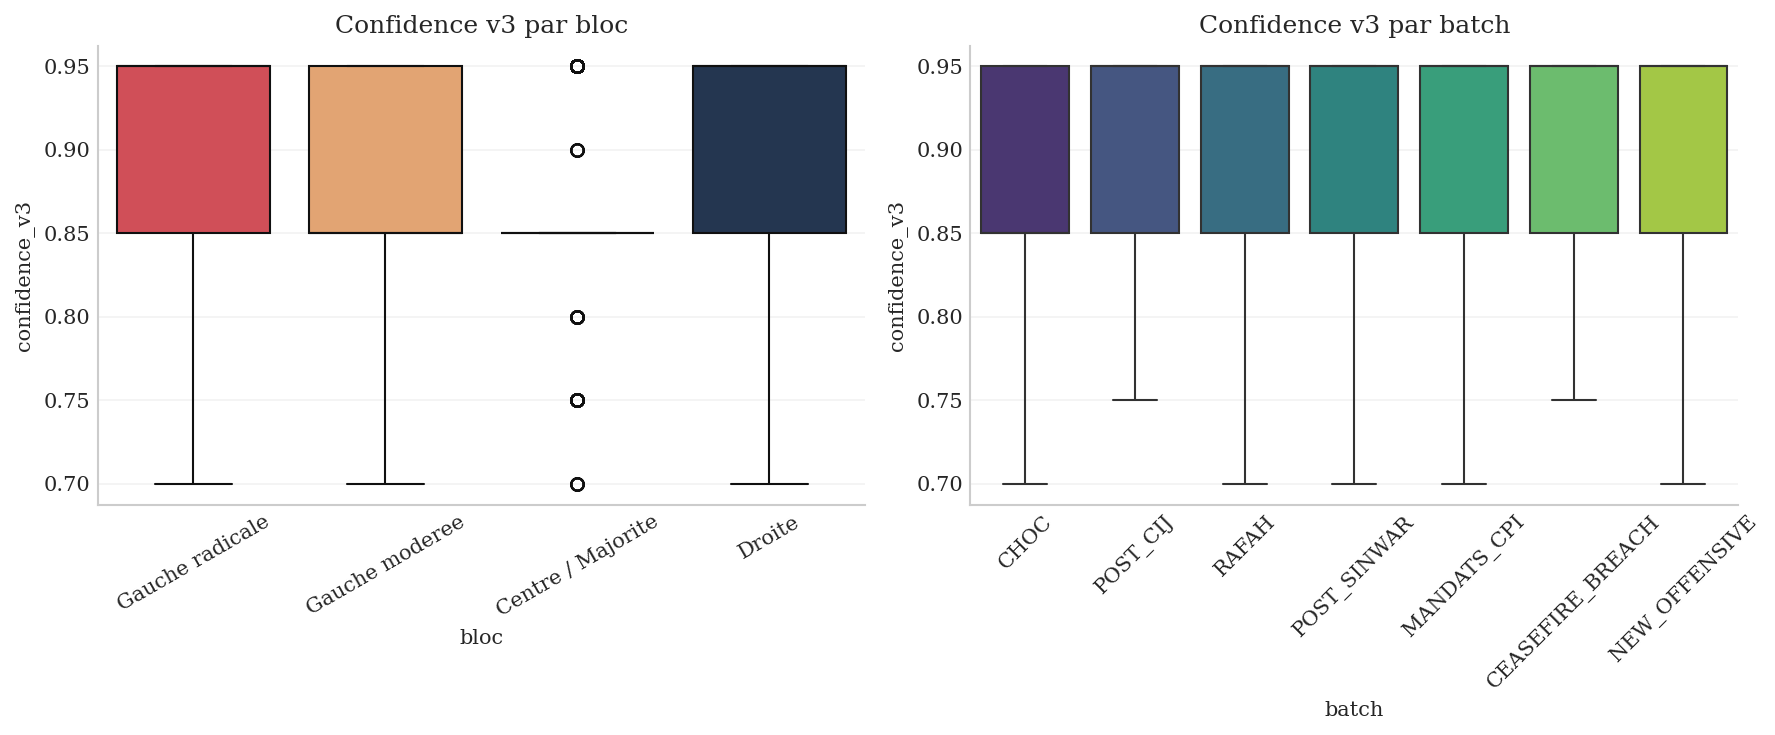

In [9]:
# Nécessite corpus_v4_clean.parquet pour confidence_v3 et period
if CORPUS_V4.exists():
    v4 = pd.read_parquet(CORPUS_V4)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.boxplot(data=v4, x="bloc", y="confidence_v3", order=BLOCS_ORDER, palette=COLORS, ax=axes[0])
    axes[0].set_title("Confidence v3 par bloc")
    axes[0].tick_params(axis="x", rotation=30)
    if "period" in v4.columns or "batch" in v4.columns:
        col = "period" if "period" in v4.columns else "batch"
        sns.boxplot(data=v4, x=col, y="confidence_v3", palette="viridis", ax=axes[1])
        axes[1].set_title(f"Confidence v3 par {col}")
        axes[1].tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig02_confidence_v3.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Corpus v4 non trouvé. Analyse confidence_v3 par bloc/period nécessite corpus_v4_clean.parquet.")
    print("Moyenne par bloc (vue_ensemble):")
    display(vue_ensemble[["bloc", "confidence_v3_moy"]])

## 1.3 Biais et attrition

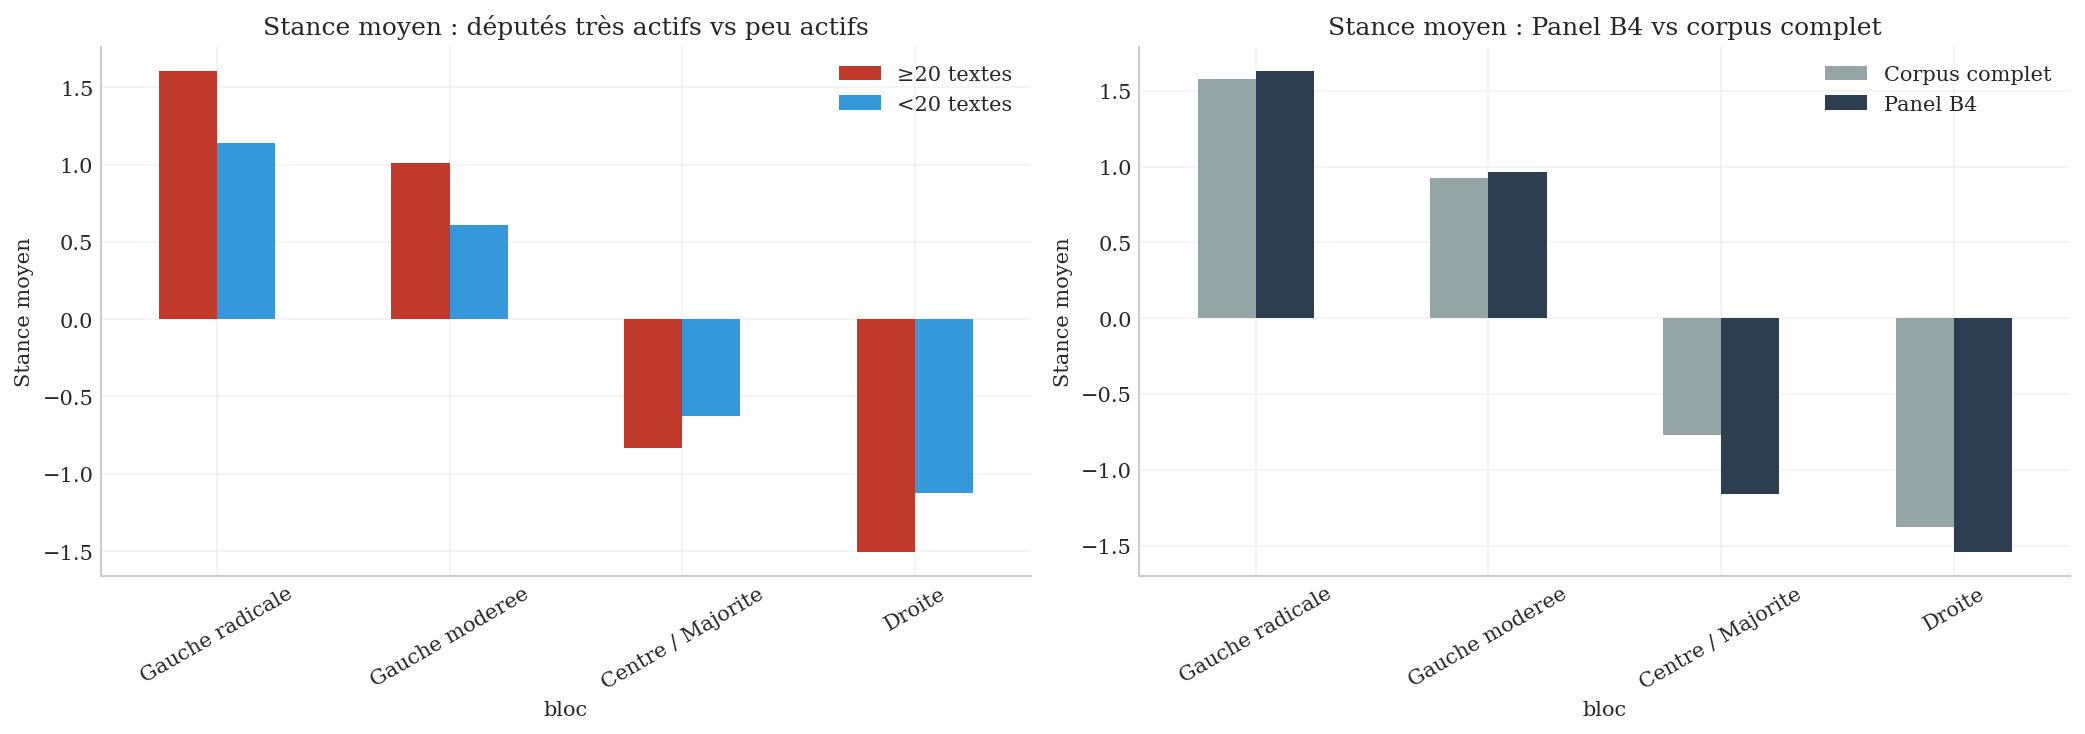

In [10]:
if CORPUS_V3.exists():
    v3 = pd.read_parquet(CORPUS_V3)
    v3["date"] = pd.to_datetime(v3["date"])
    v3["month"] = v3["date"].dt.to_period("M")
    n_textes = v3.groupby("author").size()
    v3["n_textes_author"] = v3["author"].map(n_textes)
    months_per_dep = v3.groupby("author")["month"].nunique().reset_index()
    months_per_dep.columns = ["author", "n_months"]
    panel_B4_list = months_per_dep[months_per_dep["n_months"] >= 18]["author"].tolist()
    v3["in_panel_B4"] = v3["author"].isin(panel_B4_list)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Stance ≥20 vs <20 textes
    high = v3[v3["n_textes_author"] >= 20].groupby("bloc")["stance_v3"].mean()
    low = v3[v3["n_textes_author"] < 20].groupby("bloc")["stance_v3"].mean()
    comp = pd.DataFrame({"≥20 textes": high, "<20 textes": low}).reindex(BLOCS_ORDER)
    comp.plot(kind="bar", ax=axes[0], color=["#c0392b", "#3498db"])
    axes[0].set_title("Stance moyen : députés très actifs vs peu actifs")
    axes[0].set_ylabel("Stance moyen")
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].legend()
    
    # 2. Panel B4 vs corpus complet
    stance_full = v3.groupby("bloc")["stance_v3"].mean()
    stance_b4 = v3[v3["in_panel_B4"]].groupby("bloc")["stance_v3"].mean()
    comp2 = pd.DataFrame({"Corpus complet": stance_full, "Panel B4": stance_b4}).reindex(BLOCS_ORDER)
    comp2.plot(kind="bar", ax=axes[1], color=["#95a5a6", "#2c3e50"])
    axes[1].set_title("Stance moyen : Panel B4 vs corpus complet")
    axes[1].set_ylabel("Stance moyen")
    axes[1].tick_params(axis="x", rotation=30)
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig03_survivorship_bias.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Corpus v3 non trouvé. Figure 3 nécessite corpus_v3_clean.parquet.")

In [11]:
panel_fixe = pd.read_csv(RESULTS_DIR / "panel_b4_composition.csv")
print("Composition du Panel B4 par bloc:")
display(panel_fixe)
print("\nLe Panel B4 est surreprésenté en Gauche radicale (75 % des députés).")
print("Toute analyse longitudinale sur le panel fixe doit en tenir compte.")

Composition du Panel B4 par bloc:


,bloc,n_deputes_total,n_deputes_panel,pct_deputes_panel,n_textes_panel
0,Gauche radicale,138,42,30.4,6069
1,Gauche moderee,67,9,13.4,615
2,Centre / Majorite,130,10,7.7,723
3,Droite,124,15,12.1,848



Le Panel B4 est surreprésenté en Gauche radicale (75 % des députés).
Toute analyse longitudinale sur le panel fixe doit en tenir compte.


## 1.4 Construction du panel équilibré (Panel B4)

In [12]:
THRESHOLD_B4 = 18  # mois actifs

if CORPUS_V3.exists():
    v3 = pd.read_parquet(CORPUS_V3)
    v3["date"] = pd.to_datetime(v3["date"])
    v3["month"] = v3["date"].dt.to_period("M")
    months_per_dep = v3.groupby("author")["month"].nunique().reset_index()
    months_per_dep.columns = ["author", "n_months"]
    panel_B4 = months_per_dep[months_per_dep["n_months"] >= THRESHOLD_B4]["author"].tolist()
    v3["bloc"] = v3["bloc"].astype(str)
    panel_df = v3[v3["author"].isin(panel_B4)].drop_duplicates("author")[["author", "bloc"]].copy()
    panel_df = panel_df.sort_values("bloc")
    panel_df.to_csv(RESULTS_DIR / "panel_b4.csv", index=False)
    print(f"Panel B4 : {len(panel_B4)} députés (≥{THRESHOLD_B4} mois actifs)")
    print(panel_df.groupby("bloc").size())
    display(panel_df)
else:
    print("Corpus v3 non trouvé. Export panel_B4 nécessite corpus_v3_clean.parquet.")
    print("Composition connue (NB1_panel_fixe): Gauche radicale 42, Gauche modérée 9, Centre 10, Droite 15.")

Panel B4 : 44 députés (≥18 mois actifs)
bloc
Centre / Majorite     4
Droite                4
Gauche moderee        3
Gauche radicale      33
dtype: int64


,author,bloc
4050,François Cormier-Bouligeon,Centre / Majorite
2702,Constance Le Grip,Centre / Majorite
954,Aurore Bergé,Centre / Majorite
1410,Caroline Yadan,Centre / Majorite
7003,Michèle Tabarot,Droite
5541,Julien Odoul,Droite
5138,Jérôme Buisson,Droite
1324,Bruno Bilde,Droite
3858,Olivier Faure,Gauche moderee
5094,Jérôme Guedj,Gauche moderee


## Synthèse et limitations

- **Corpus** : 10 774 textes, 4 blocs, fort déséquilibre Gauche radicale.
- **Validation** : Accord v3/v4 ρ = 0,86, excellente fiabilité.
- **Attrition** : Forte baisse des députés actifs dans le temps.
- **Panel B4** : 44 députés actifs ≥18 mois ; surreprésentation Gauche radicale (75 %).
- **Limitations** : Les analyses nécessitant le corpus brut (confusion matrix, survivorship détaillé) requièrent les fichiers parquet.

---

## Chiffres clés (résumé)

| Indicateur | Valeur |
|------------|--------|
| Corpus v3 | 10 774 textes |
| Corpus v4 | 5 905 textes |
| G.rad % corpus | 63,5 % |
| Ratio Twitter/AN G.rad | 10,19 |
| Ratio Twitter/AN Centre | 1,73 |
| Attrition | 211 → 34 députés actifs |
| Accord v3/v4 (Spearman ρ) | 0,86 |
| Accord ±1 point | 95,3 % |
| Panel B4 | 44 députés (33 G.rad, 3 G.mod, 4 Centre, 4 Droite) |